In [3]:
# Check Using GPU or CPU using torch
import torch
print(torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

True
cuda


/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park/data
       t-1   t-2   t-3   t-4   t-5   t-6   t-7   t-8   t-9  t-10  ...  t-19  \
26    28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  28.5  ...  29.3   
27    28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  ...  29.3   
28    28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  ...  25.2   
31    28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  ...  27.4   
32    29.0  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  ...  27.5   
...    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
8637  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  13.2  ...  16.8   
8638  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  ...  16.5   
8639  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  ...  18.8   
8640  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  ...  19.2   
8641  15.9  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  1

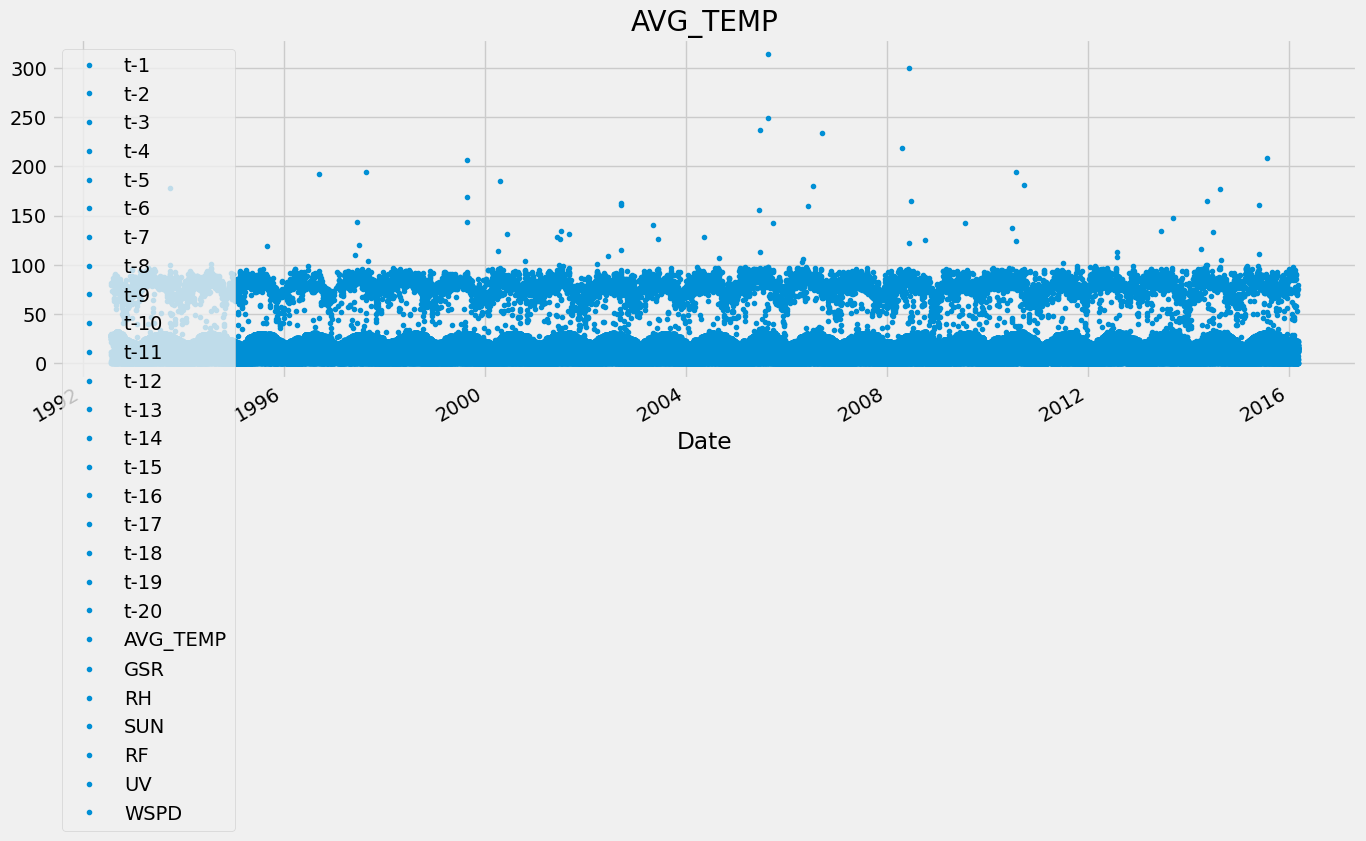

In [13]:
# AVG_TEMP_DATA = os.getcwd() + "\data\CLMTEMP_KP_.csv"
# GSR_DATA = os.getcwd() + "\data\daily_KP_GSR_ALL.csv"
# RH_DATA = os.getcwd() + "\data\daily_KP_RH_ALL.csv"
# SUN_DATA = os.getcwd() + "\data\daily_KP_SUN_ALL.csv"
# RF_DATA = os.getcwd() + "\data\daily_KP_RF_ALL.csv"
# UV_DATA = os.getcwd() + "\data\daily_KP_UV_ALL.csv"
# WSPD_DATA = os.getcwd() + "\data\daily_KP_WSPD_ALL.csv"

import os

parent_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(parent_dir, "data")
AVG_TEMP_DATA = os.path.join(data_dir, "CLMTEMP_KP_.csv")
GSR_DATA = os.path.join(data_dir, "daily_KP_GSR_ALL.csv")
RH_DATA = os.path.join(data_dir, "daily_KP_RH_ALL.csv")
SUN_DATA = os.path.join(data_dir, "daily_KP_SUN_ALL.csv")
RF_DATA = os.path.join(data_dir, "daily_KP_RF_ALL.csv")
UV_DATA = os.path.join(data_dir, "daily_KP_UV_ALL.csv")
WSPD_DATA = os.path.join(data_dir, "daily_KP_WSPD_ALL.csv") 

print(data_dir)

# Preprocess data
import pandas as pd
from loguru import logger
try:
    AVG_TEMP_df = pd.read_csv(AVG_TEMP_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    GSR_df = pd.read_csv(GSR_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    RH_df = pd.read_csv(RH_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    SUN_df = pd.read_csv(SUN_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    RF_df = pd.read_csv(RF_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    UV_df = pd.read_csv(UV_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    WSPD_df = pd.read_csv(WSPD_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
except:
    logger.error("Error reading data files")
    exit(1)
    
from utils.DataPreprocessing import DataJoining
join_df = DataJoining(AVG_TEMP_df, GSR_df, RH_df, SUN_df, RF_df, UV_df, WSPD_df)
# logger.info(join_df.info())
# logger.info(join_df.isnull().sum())

# GSR  RH  SUN   RF   UV  WSPD
join_df['GSR'] = pd.to_numeric(join_df['GSR'], errors='coerce')
join_df['RH'] = pd.to_numeric(join_df['RH'], errors='coerce')
join_df['SUN'] = pd.to_numeric(join_df['SUN'], errors='coerce')
join_df['RF'] = pd.to_numeric(join_df['RF'], errors='coerce')
join_df['UV'] = pd.to_numeric(join_df['UV'], errors='coerce')
join_df['WSPD'] = pd.to_numeric(join_df['WSPD'], errors='coerce')

from pandas import DataFrame, concat

# transform a time series dataset into a supervised learning dataset
def series_to_supervised(df:DataFrame, time_series_key, n_in=0, n_out=0, dropnan=True):
    temp = df.copy()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        # cols.append(df.shift(i))
        # add new column
        # temp['t-'+str(i)] = temp['t'].shift(i)
        temp.insert(0, 't-'+str(i), temp[time_series_key].shift(i))
    # forecast sequence (t, t+1, ... t+n)
    for i in range(1, n_out+1):
        # cols.append(df.shift(-i))
        # add new column
        # temp['t+'+str(i)] = temp['t'].shift(-i)
        temp.insert(0, 't+'+str(i), temp[time_series_key].shift(-i))
    # # put it all together
    # agg = concat(cols, axis=1)
    # drop rows with NaN values
    if dropnan:
        temp.dropna(inplace=True)
    return temp

join_df = series_to_supervised(join_df, "AVG_TEMP", 20, 0)

print(join_df)

# columns are t-1 ... t-50  Date  AVG_TEMP  GSR  RH  SUN  RF  UV  WSPD
# plot the data with dat in x axis, AVG_TEMP in y axis
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates
# make a function that accept the range of data to plot
import seaborn as sns
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

def plot_data(df:DataFrame, start=None, end=-1, n=100):
    temp = df.copy()
    temp = temp.set_index('Date')
    temp.index = pd.to_datetime(temp.index)
    print(temp)
    
    cols = temp.columns.tolist()
    cols.remove('AVG_TEMP')
    # temp drop other features except AVG_TEMP
    # temp = temp.drop(columns=cols) # drop other features except AVG_TEMP
    
    # if not start:
    #     start = len(temp) - n
    # if end == -1:
    #     end = len(temp)
        
    # print(start, end)
    # temp = temp[start:end]
    
    temp.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='AVG_TEMP')
    
    plt.show()
    return temp

df = plot_data(join_df, n=400)


In [14]:
def create_features(df:DataFrame):
    """
    Create time series features based on time series index.
    """
    
    df = df.copy()
    # df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

print(df)
df = create_features(df)
print(df)

             t-1   t-2   t-3   t-4   t-5   t-6   t-7   t-8   t-9  t-10  ...  \
Date                                                                    ...   
1992-07-27  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  28.5  ...   
1992-07-28  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  ...   
1992-07-29  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  ...   
1992-08-01  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  ...   
1992-08-02  29.0  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  ...   
...          ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
2016-02-28  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  13.2  ...   
2016-02-29  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  ...   
2016-03-01  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  ...   
2016-03-02  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  ...   
2016-03-03  15.9  15.8  18.5  16.3  15.5  14.9  14.3

In [ ]:

# Split train data into train and validation
from sklearn.model_selection import train_test_split

x_df = df.drop(columns=['AVG_TEMP'])
y_df = df['AVG_TEMP']

x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.3)

cuda_kwargs = {
    'num_workers' : 4,
    'pin_memory' : True,
    'batch_size' : 64,
    'shuffle' : True
}

# use data loader to load data
from torch.utils.data import DataLoader, TensorDataset
train_data = TensorDataset(torch.from_numpy(x_train.values).float(), torch.from_numpy(y_train.values).long())
test_data = TensorDataset(torch.from_numpy(x_test.values).float(), torch.from_numpy(y_test.values).long())

train_dataloader = DataLoader(train_data, **cuda_kwargs)
test_dataloader = DataLoader(test_data, **cuda_kwargs)


In [ ]:
# Build a model
from torch import nn
from torch import optim

# Define a model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.conv = nn.Sequential(
            nn.Linear(4, 512),
            nn.ReLU(),
            # nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            # nn.Dropout(p=0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            # nn.Dropout(p=0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            # nn.Dropout(p=0.2),
            nn.Linear(64, 3),
        )
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.conv(x).float()
        logits = self.softmax(x)
        return logits
    
model = NeuralNetwork().to(device)

for name, param in model.conv.named_parameters():
    param.requires_grad = True
    
print(model)

In [ ]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Define optimizer
# optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9) 
optimizer = optim.Adam(model.parameters(), lr=0.003)

In [ ]:
from tqdm import tqdm
from loguru import logger

# each epoch
@logger.catch
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    
    # Turn on training mode
    model.train()
    train_loss, correct = 0, 0
    for x, y in tqdm(dataloader):
        # Send data to GPU
        
        y = y.squeeze(1)
        
        x, y = x.to(device), y.to(device)
        
        # Forward propagation
        pred = model(x)
        loss = loss_fn(pred, y)
        
        # Backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Record loss
        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    train_loss /= len(dataloader)
    correct /= size

    print(f" Train accuracy: {(100*correct):>0.1f}%, Avg loss: {train_loss:>8f}")
    print(train_loss, correct)
    return train_loss, correct

In [ ]:
# Test function
@logger.catch
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Turn on evalution mode
    model.eval()
    test_loss, correct = 0, 0

    # Turn off gradient descent
    with torch.no_grad():
        for x, y in tqdm(dataloader):
            
            y = y.squeeze(1)
            x, y = x.to(device), y.to(device)
            pred = model(x)

            # record loss
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size

    print(f" Test accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}")
    return correct

In [ ]:
# Total training epochs
epochs = 100
training_losses = []
training_accuracy = []
testing_accuracy = []
for t in range(epochs):
    print('\n', "=" * 15, "Epoch", t + 1, "=" * 15)
    loss, train_accuracy = train(train_dataloader, model, loss_fn, optimizer)
    test_accuracy = test(test_dataloader, model, loss_fn)
    training_losses.append(loss)
    training_accuracy.append(train_accuracy)
    testing_accuracy.append(test_accuracy)

print(" Done!")

In [ ]:
# Plot the loss
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(training_losses)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.show()


In [ ]:
# plot accuracy
plt.plot(training_accuracy, label='training accuracy')
plt.plot(testing_accuracy, label='testing accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.show()


In [ ]:
# print best accuracy
print(max(training_accuracy))
print(max(testing_accuracy))


In [ ]:
# predict the target
temp = x_target
temp = temp.values
temp = torch.from_numpy(temp).float()
temp = temp.to(device)
pred = model(temp)
pred = pred.argmax(1)
pred = pred.cpu().numpy()
pred = pd.DataFrame(pred, columns=['Predicted'])
#name the index to Id
pred.index.name = 'Id'
pred.to_csv('result.csv')

print(pred)